Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Loading dataset

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\cfafrica-data-team-outbreak-covid19-data-openafrica-uploads-kenya-diabetes.csv")

3. EDA

In [6]:
df.head()

,Geography,Percentage of the Population that reported having Diabetes
0,Kenya,1.1
1,Mombasa,0.7
2,Kwale,0.7
3,Kilifi,1.3
4,Tana River,0.0


In [7]:
df.drop(0)

,Geography,Percentage of the Population that reported having Diabetes
1,Mombasa,0.7
2,Kwale,0.7
3,Kilifi,1.3
4,Tana River,0.0
5,Lamu,2.2
6,Taita / Taveta,0.8
7,Garissa,1.9
8,Wajir,2.0
9,Mandera,0.4
10,Marsabit,0.7


In [8]:
df.isnull().sum()

Geography                                                     0
Percentage of the Population that reported having Diabetes    0
dtype: int64

4. Summary statistics

In [10]:
print("Mean %:", df["Percentage of the Population that reported having Diabetes"].mean())

Mean %: 1.0979166666666667


In [11]:
print("Median %:" , df["Percentage of the Population that reported having Diabetes"].median())

Median %: 0.8


In [12]:
print("County with lowest diabetes %:", df.loc[df["Percentage of the Population that reported having Diabetes"].idxmin(), "Geography"])

County with lowest diabetes %: Tana River


In [13]:
print("County with highest diabetes %:", df.loc[df["Percentage of the Population that reported having Diabetes"].idxmax(), "Geography"])

County with highest diabetes %: Nyeri


5. Visualizations

A histogram that shows the distribution of diabetes rates across the counties

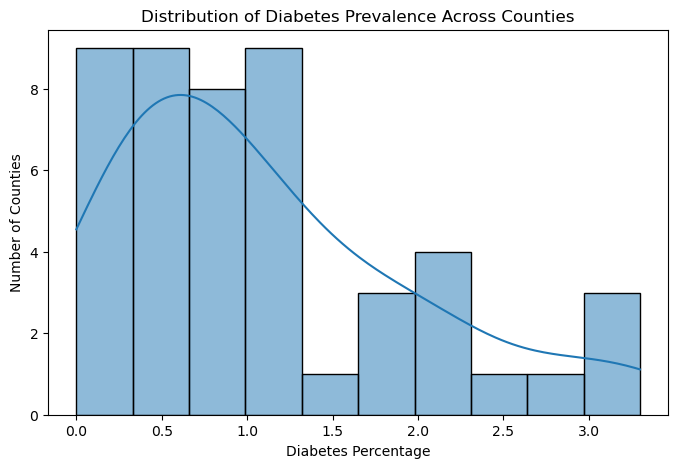

In [136]:
plt.figure(figsize=(8,5))

sns.histplot(df["Percentage of the Population that reported having Diabetes"], bins=10, kde=True)

plt.title("Distribution of Diabetes Prevalence Across Counties")
plt.xlabel("Diabetes Percentage")
plt.ylabel("Number of Counties")

plt.show()


2. A boxplot to detect outliers

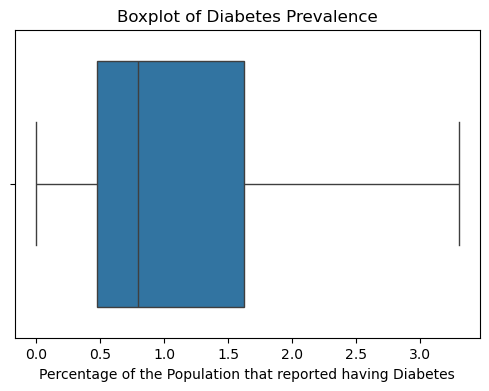

In [132]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Percentage of the Population that reported having Diabetes"])

plt.title("Boxplot of Diabetes Prevalence")

plt.show()


3. A barchart of all the counties

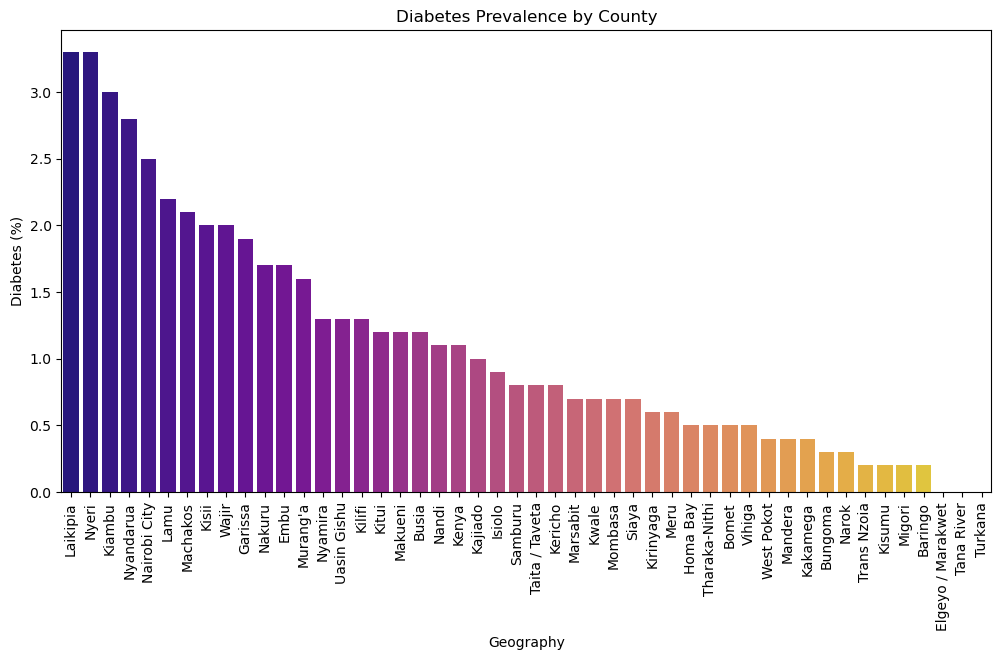

In [120]:
plt.figure(figsize=(12,6))

df_sorted = df.sort_values("Percentage of the Population that reported having Diabetes", ascending=False)

sns.barplot(
    x="Geography",
    y="Percentage of the Population that reported having Diabetes",
    data=df_sorted,
    palette = "plasma"
)

plt.xticks(rotation=90)
plt.title("Diabetes Prevalence by County")
plt.ylabel("Diabetes (%)")

plt.show()


4. Top 10 counties with diabetes

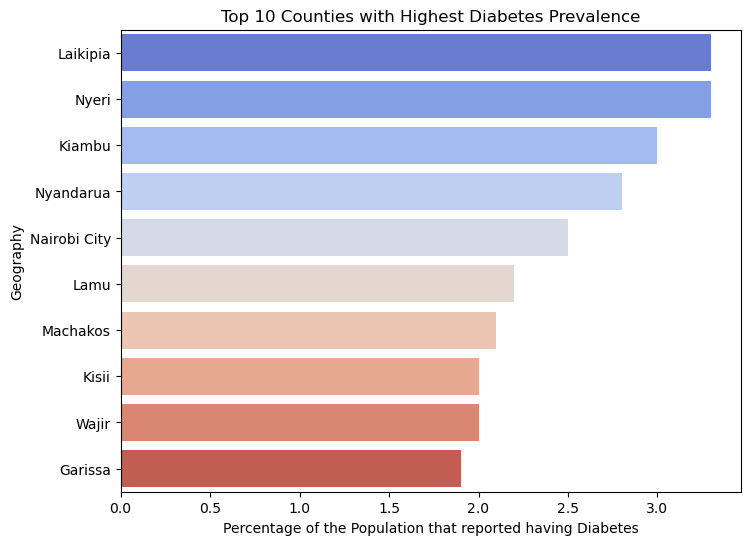

In [124]:
top10 = df.sort_values("Percentage of the Population that reported having Diabetes", ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Percentage of the Population that reported having Diabetes",
    y="Geography",
    palette = "coolwarm",
    data=top10
)

plt.title("Top 10 Counties with Highest Diabetes Prevalence")

plt.show()


5.Bottom 10 counties with diabetes

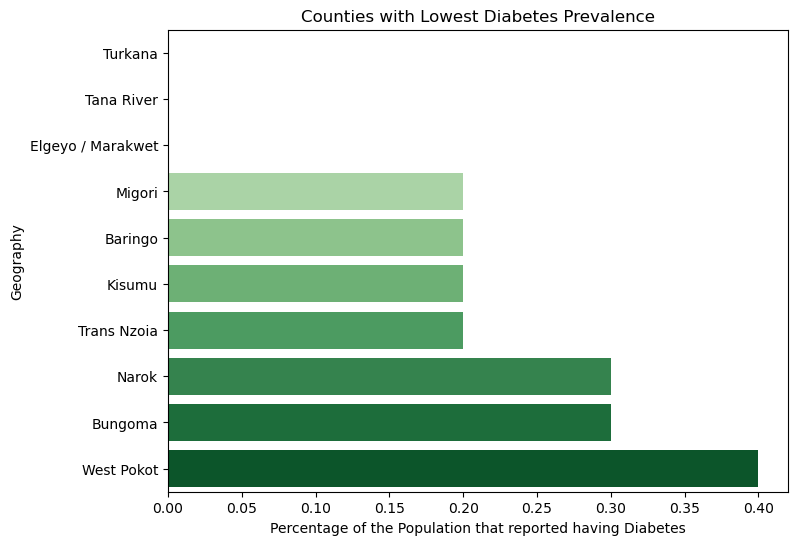

In [138]:
bottom10 = df.sort_values("Percentage of the Population that reported having Diabetes").head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Percentage of the Population that reported having Diabetes",
    y="Geography",
    palette = "Greens",
    data=bottom10
)

plt.title("Counties with Lowest Diabetes Prevalence")

plt.show()


3. Piechart comparing the distribution of the top 5 counties

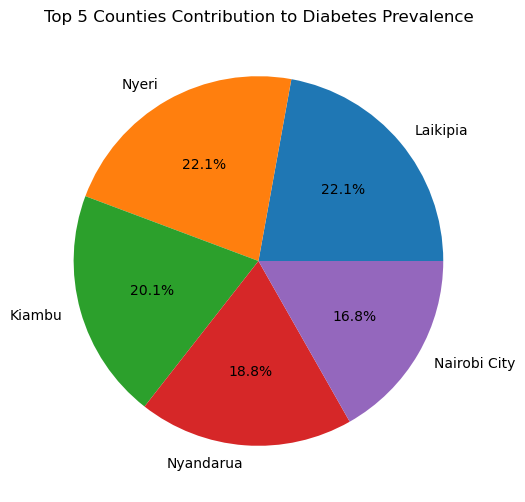

In [26]:
top5 = df.sort_values("Percentage of the Population that reported having Diabetes", ascending=False).head(5)

plt.figure(figsize=(6,6))

plt.pie(
    top5["Percentage of the Population that reported having Diabetes"],
    labels=top5["Geography"],
    autopct='%1.1f%%'
)

plt.title("Top 5 Counties Contribution to Diabetes Prevalence")

plt.show()


Heatmap

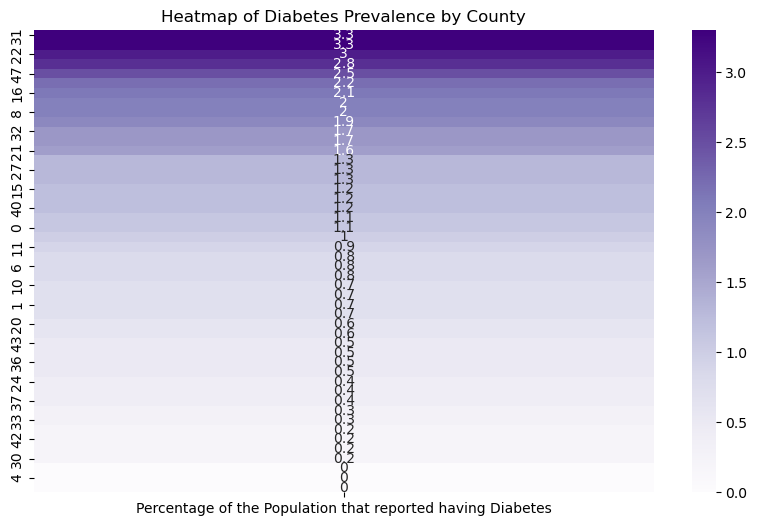

In [99]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[["Percentage of the Population that reported having Diabetes"]].sort_values(by="Percentage of the Population that reported having Diabetes", ascending=False),
    cmap="Purples",
    annot=True
)

plt.title("Heatmap of Diabetes Prevalence by County")

plt.show()


In [65]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


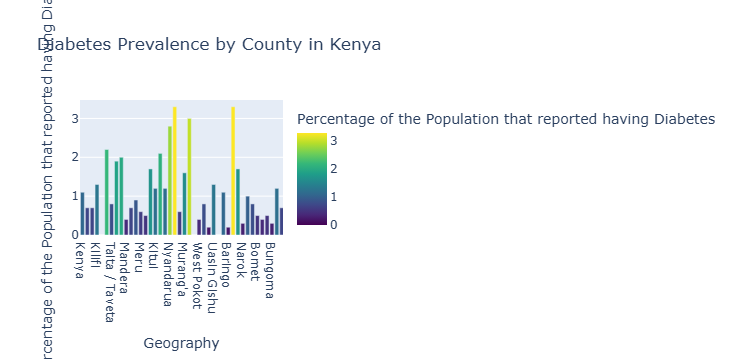

In [91]:
import plotly.express as px

fig = px.bar(
    df,
    x="Geography",
    y="Percentage of the Population that reported having Diabetes",
    title="Diabetes Prevalence by County in Kenya",
    color="Percentage of the Population that reported having Diabetes",
    color_continuous_scale="viridis"
)

fig.show()


 Choropleth map

In [140]:
pip install plotly geopandas


   ---------------------------------------- 0.0/342.5 kB ? eta -:--:--
   --- ------------------------------------ 30.7/342.5 kB 1.4 MB/s eta 0:00:01
   ---- ---------------------------------- 41.0/342.5 kB 495.5 kB/s eta 0:00:01
   ---- ---------------------------------- 41.0/342.5 kB 495.5 kB/s eta 0:00:01
   ------ -------------------------------- 61.4/342.5 kB 328.2 kB/s eta 0:00:01
   ---------- ---------------------------- 92.2/342.5 kB 403.5 kB/s eta 0:00:01
   --------------- ---------------------- 143.4/342.5 kB 502.3 kB/s eta 0:00:01
   ------------------- ------------------ 174.1/342.5 kB 551.6 kB/s eta 0:00:01
   -------------------- ----------------- 184.3/342.5 kB 507.5 kB/s eta 0:00:01
   ---------------------- --------------- 204.8/342.5 kB 518.8 kB/s eta 0:00:01
   ----------------------------------- -- 317.4/342.5 kB 656.4 kB/s eta 0:00:01
   -------------------------------------- 342.5/342.5 kB 664.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2

In [157]:
df = df[df["Geography"] != "Kenya"]

df.head()

,Geography,Percentage of the Population that reported having Diabetes
1,Mombasa,0.7
2,Kwale,0.7
3,Kilifi,1.3
4,Tana River,0.0
5,Lamu,2.2


In [161]:
from urllib.request import urlopen
import json

url = "https://raw.githubusercontent.com/Mondieki/kenya-counties-subcounties/master/counties.json"

with urlopen(url) as response:
    counties_data = json.load(response)

print(len(counties_data))  
print(counties_data[0])    

47
{'name': 'Baringo', 'capital': 'Kabarnet', 'code': 30, 'sub_counties': ['Baringo central', 'Baringo north', 'Baringo south', 'Eldama ravine', 'Mogotio', 'Tiaty']}


In [191]:
pip install folium


   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/113.4 kB ? eta -:--:--
   ---------- ---------------------------- 30.7/113.4 kB 660.6 kB/s eta 0:00:01
   ---------- ---------------------------- 30.7/113.4 kB 660.6 kB/s eta 0:00:01
   -------------- ------------------------ 41.0/113.4 kB 245.8 kB/s eta 0:00:01
   ---------------------------- ---------- 81.9/113.4 kB 353.1 kB/s eta 0:00:01
   ------------------------------- ------- 92.2/113.4 kB 350.1 kB/s eta 0:00:01
   ------------------------------- ------- 92.2/113.4 kB 350.1 kB/s eta 0:00:01
   -------------------------------------- 113.4/113.4 kB 287.3 kB/s eta 0:00:00


In [208]:
import folium
import geopandas as gpd
import pandas as pd
import json


url = "https://raw.githubusercontent.com/mikelmaron/kenya-election-data/master/data/counties.geojson"
gdf = gpd.read_file(url)
gdf_counties = gdf.dissolve(by="COUNTY_NAM").reset_index()


counties_geo = json.loads(gdf_counties.to_json())
for feature in counties_geo["features"]:
    feature["id"] = feature["properties"]["COUNTY_NAM"]


In [212]:
gdf_counties["COUNTY_NAM"].unique()


array(['BARINGO', 'BOMET', 'BUNGOMA', 'BUSIA', 'ELEGEYO-MARAKWET', 'EMBU',
       'GARISSA', 'HOMA BAY', 'ISIOLO', 'KAJIADO', 'KAKAMEGA', 'KERICHO',
       'KIAMBU', 'KILIFI', 'KIRINYAGA', 'KISII', 'KISUMU', 'KITUI',
       'KWALE', 'LAIKIPIA', 'LAMU', 'MACHAKOS', 'MAKUENI', 'MANDERA',
       'MARSABIT', 'MERU', 'MIGORI', 'MOMBASA', "MURANG'A", 'NAIROBI',
       'NAKURU', 'NANDI', 'NAROK', 'NYAMIRA', 'NYANDARUA', 'NYERI',
       'SAMBURU', 'SIAYA', 'TAITA TAVETA', 'TANA RIVER',
       'THARAKA - NITHI', 'TRANS NZOIA', 'TURKANA', 'UASIN GISHU',
       'VIHIGA', 'WAJIR', 'WEST POKOT'], dtype=object)

In [214]:
df["Geography"].unique()

array(['Mombasa', 'Kwale', 'Kilifi', 'Tana River', 'Lamu',
       'Taita / Taveta', 'Garissa', 'Wajir', 'Mandera', 'Marsabit',
       'Isiolo', 'Meru', 'Tharaka-Nithi', 'Embu', 'Kitui', 'Machakos',
       'Makueni', 'Nyandarua', 'Nyeri', 'Kirinyaga', "Murang'A", 'Kiambu',
       'Turkana', 'West Pokot', 'Samburu', 'Trans Nzoia', 'Uasin Gishu',
       'Elgeyo / Marakwet', 'Nandi', 'Baringo', 'Laikipia', 'Nakuru',
       'Narok', 'Kajiado', 'Kericho', 'Bomet', 'Kakamega', 'Vihiga',
       'Bungoma', 'Busia', 'Siaya', 'Kisumu', 'Homa Bay', 'Migori',
       'Kisii', 'Nyamira', 'Nairobi City'], dtype=object)

Normalization

In [217]:
df["Geography"] = df["Geography"].str.strip().str.title()

for feature in counties_geo["features"]:
    feature["id"] = feature["id"].strip().title()


Case issues

In [221]:
for feature in counties_geo["features"]:
    name = feature["properties"]["COUNTY_NAM"].upper() 
    name = name.replace(" - ", "-").replace(" COUNTY", "").strip()
    feature["id"] = name


In [225]:
df["Geography"] = df["Geography"].str.upper().str.replace(" / ", "-").str.replace(" CITY", "").str.strip()

In [227]:
geo_counties = [feature["id"] for feature in counties_geo["features"]]
df_counties = df["Geography"].tolist()
print("In CSV but not in GeoJSON:", set(df_counties) - set(geo_counties))
print("In GeoJSON but not in CSV:", set(geo_counties) - set(df_counties))


In CSV but not in GeoJSON: {'TAITA-TAVETA', 'ELGEYO-MARAKWET'}
In GeoJSON but not in CSV: {'ELEGEYO-MARAKWET', 'TAITA TAVETA'}


Manual mapping

In [230]:
fix_counties = {
    "TAITA-TAVETA": "TAITA TAVETA",
    "ELGEYO-MARAKWET": "ELEGEYO-MARAKWET"
}


df["Geography"] = df["Geography"].replace(fix_counties)


In [244]:
import folium

diabetes_dict = dict(zip(df['Geography'].str.upper(), 
                         df['Percentage of the Population that reported having Diabetes']))

for feature in counties_geo['features']:
    county_name = feature['properties']['COUNTY_NAM'].upper()
    feature['properties']['Diabetes'] = diabetes_dict.get(county_name, "No data")

m = folium.Map(location=[0.0236, 37.9062], zoom_start=6)

folium.Choropleth(
    geo_data=counties_geo,
    name="choropleth",
    data=df,
    columns=["Geography", "Percentage of the Population that reported having Diabetes"],
    key_on="feature.id",
    fill_color="PuBu",
    fill_opacity=0.7,
    line_opacity=0,
    legend_name="Diabetes Prevalence (%)"
).add_to(m)

folium.GeoJson(
    counties_geo,
    name="County Borders",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 1,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['COUNTY_NAM', 'Diabetes'],
        aliases=['County:', 'Diabetes %:'],
        localize=True
    )
).add_to(m)

folium.LayerControl().add_to(m)
m
